# Decomposing the Evaluation: Fit, Semantics, Style, and Substance

Three questions structure this notebook:

**(a) What does the score depend on, and how much?** Is it mostly the candidate's
intrinsic quality, or the writing? Two angles: comparing CV Only / CV + Cover Letter /
Cover Letter Only as three conditions, and building up R² block by block within each.

**(b) Genuine vs. inflated semantic similarity.** The letter's cosine similarity to the
job ad / CV can come from two sources: a *genuine* signal (the CV really does match the
job) or *inflation* (the writer echoes job-ad or CV language beyond what the underlying
match actually justifies). Do evaluators reward the inflated part, or see through it?

**(c) Style vs. substance, per evaluator.** From an evaluation standpoint, how much does
each evaluator lean on its own holistic sense of the candidate ("substance") vs. the
letter's style — and within style, on which specific feature?

**Contents:**
1. What the score depends on, and how much (a)
2. Genuine vs. inflated semantic similarity (b)
3. Style vs. substance, per evaluator (c)
4. Key takeaways


In [1]:
import warnings; warnings.filterwarnings("ignore")
from IPython.display import Image, display
%matplotlib inline

CL_DIR = "output_plots/cl_features_no_gemini2"


---
## 1. What Does the Score Depend On, and How Much?

One figure, three panels — **CV Only, CV + Cover Letter, Cover Letter Only** — sharing one
R² scale so bar length is directly comparable across conditions. Each panel builds up R²
through the same clean, non-overlapping trunk: **Job → Substance → Evaluator**. Where a
cover letter exists, that trunk then branches into two *alternative* endpoints (not a
sequence of each other, both computed from `+ Evaluator`): **branch A (`+ Writer`)**, a
catch-all categorical label, vs. **branch B (`+ Text Features`)**, the same variance
decomposed into the measured style and semantic features instead. CV Only has no letter,
so it stops at `+ Evaluator`.

**`Substance`** here is the **pooled average CV-only score across all 9 evaluators** for
that (Job, CV) pair — a single consensus quality measure usable across every evaluator in
one shared trunk. This is the same underlying measurement as `Substance` in §2 below,
just aggregated differently: §2 uses each evaluator's *own* CV-only score
(self-referential, analyzed one evaluator at a time), which wouldn't work here — a single
combined trunk needs one shared value, and using each evaluator's own score would also be
circular specifically for the CV Only panel, where the outcome being predicted already
*is* that same self-referential number. Averaging across evaluators sidesteps both
problems: any one evaluator's own score is only 1/9 of the average, so there's real,
non-circular signal left for it to explain.


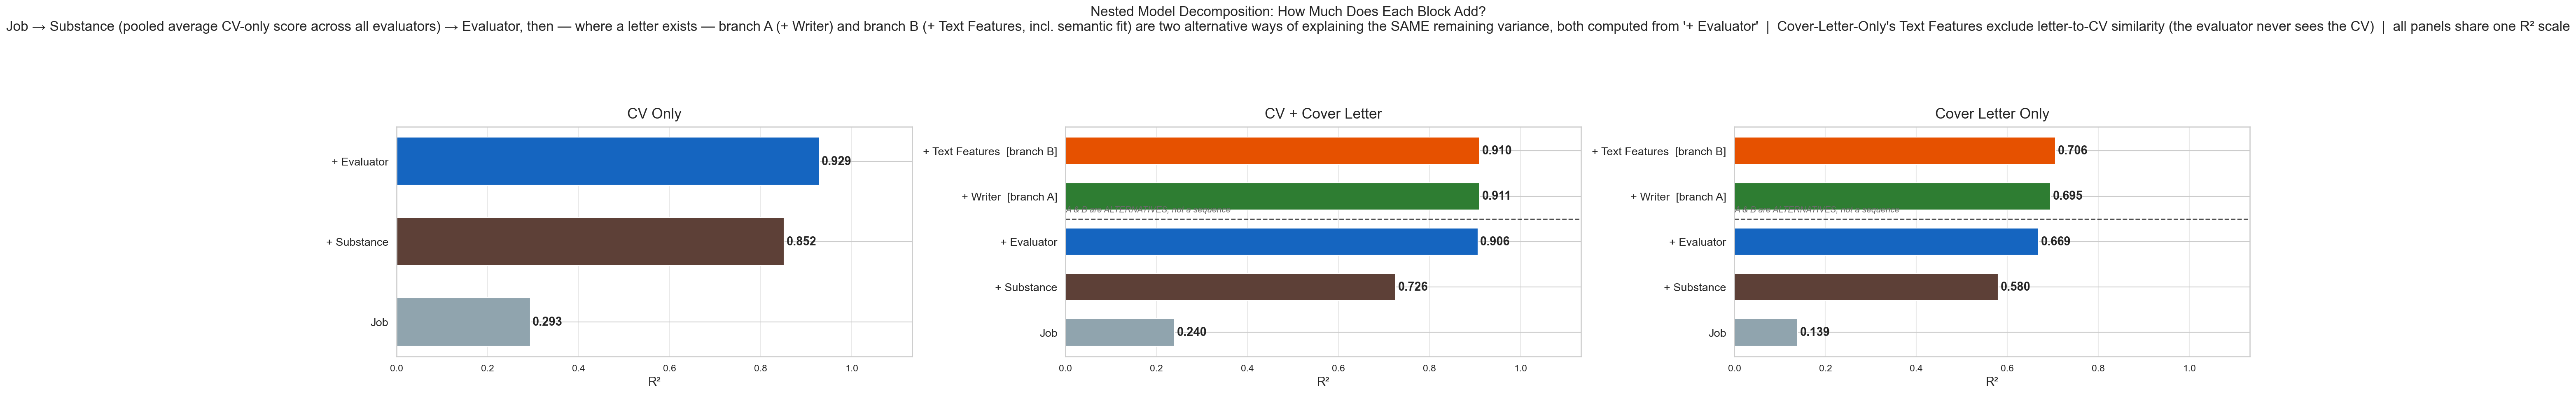

In [2]:
display(Image(f"{CL_DIR}/nested_model_decomposition.png", width=1400))

**Key finding — does the letter add anything, or just mask the CV?** CV Only's ceiling
(Job + Substance + Evaluator, no letter possible) is **R² = 0.929** — evaluators agree with
each other on CV quality so strongly that knowing the consensus view essentially tells you
what any individual evaluator will say. Adding a cover letter on top of the CV (CV + Cover
Letter) reaches a slightly **lower** ceiling, R² = 0.910/0.911 — the letter doesn't add
anything beyond what the CV and its consensus quality already provide; if anything it adds
a touch of extra noise. Remove the CV entirely (Cover-Letter-Only) and the ceiling drops to
**0.695–0.706** — still substantial (most of a candidate's consensus quality still comes
through in the letter alone), but clearly a weaker signal than having the CV directly.

**Key finding — what actually drives the score?** `Substance` is overwhelmingly the
largest single jump in every condition (+0.559 CV Only, +0.486 CV+CL, +0.441
Cover-Letter-Only) — dwarfing `+ Evaluator` (+0.078 to +0.180), which was already the
clear second-place factor in the earlier version of this analysis. Consensus candidate
quality is, by a wide margin, the dominant thing driving the score everywhere, even when
no evaluator individually sees the CV. **Branch A and branch B are close but not
identical**: in CV+CL they're essentially tied (0.911 vs. 0.910), but in Cover-Letter-Only
branch B (`+ Text Features`) is modestly ahead of branch A (`+ Writer`) — 0.706 vs. 0.695 —
meaning once the CV is gone, knowing the letter's actual measured content explains slightly
*more* than just knowing who wrote it.


---
## 2. Style vs. Substance, Per Evaluator

Two plots, deliberately built to be the same analysis at two levels of zoom, not two
separate analyses. Both use the **exact same baseline (Job identity only) and the exact
same blocks**: **Substance** (that evaluator's own CV-only score for this candidate —
self-referential, matched by Evaluator, not a pooled or external ground truth), **Job-Ad
Fit** and **CV Consistency** (the letter's own cosine similarity to the job ad / CV — CV
Consistency dropped in Cover-Letter-Only, since the evaluator never sees the CV there),
and the **4 style categories** (Length & Structure, Language Complexity, Sentiment &
Affect, Emotions). Writer identity is deliberately *not* a baseline control, so
between-writer style variation counts toward the style blocks rather than being absorbed
away.

**The link between the two plots:** the first establishes the big picture — of an
evaluator's explainable score, how much is Substance vs. Job-Ad Fit vs. CV Consistency
vs. style (each of the 4 categories combined into one number)? The second takes that same
decomposition and **zooms into the style portion specifically** — same baseline, same
blocks, so each style category's total in the second plot is numerically identical to
that category's bar in the first. It doesn't re-scope the question; it just asks "which
feature *inside* that slice is doing the work?"

### 2a. The Big Picture


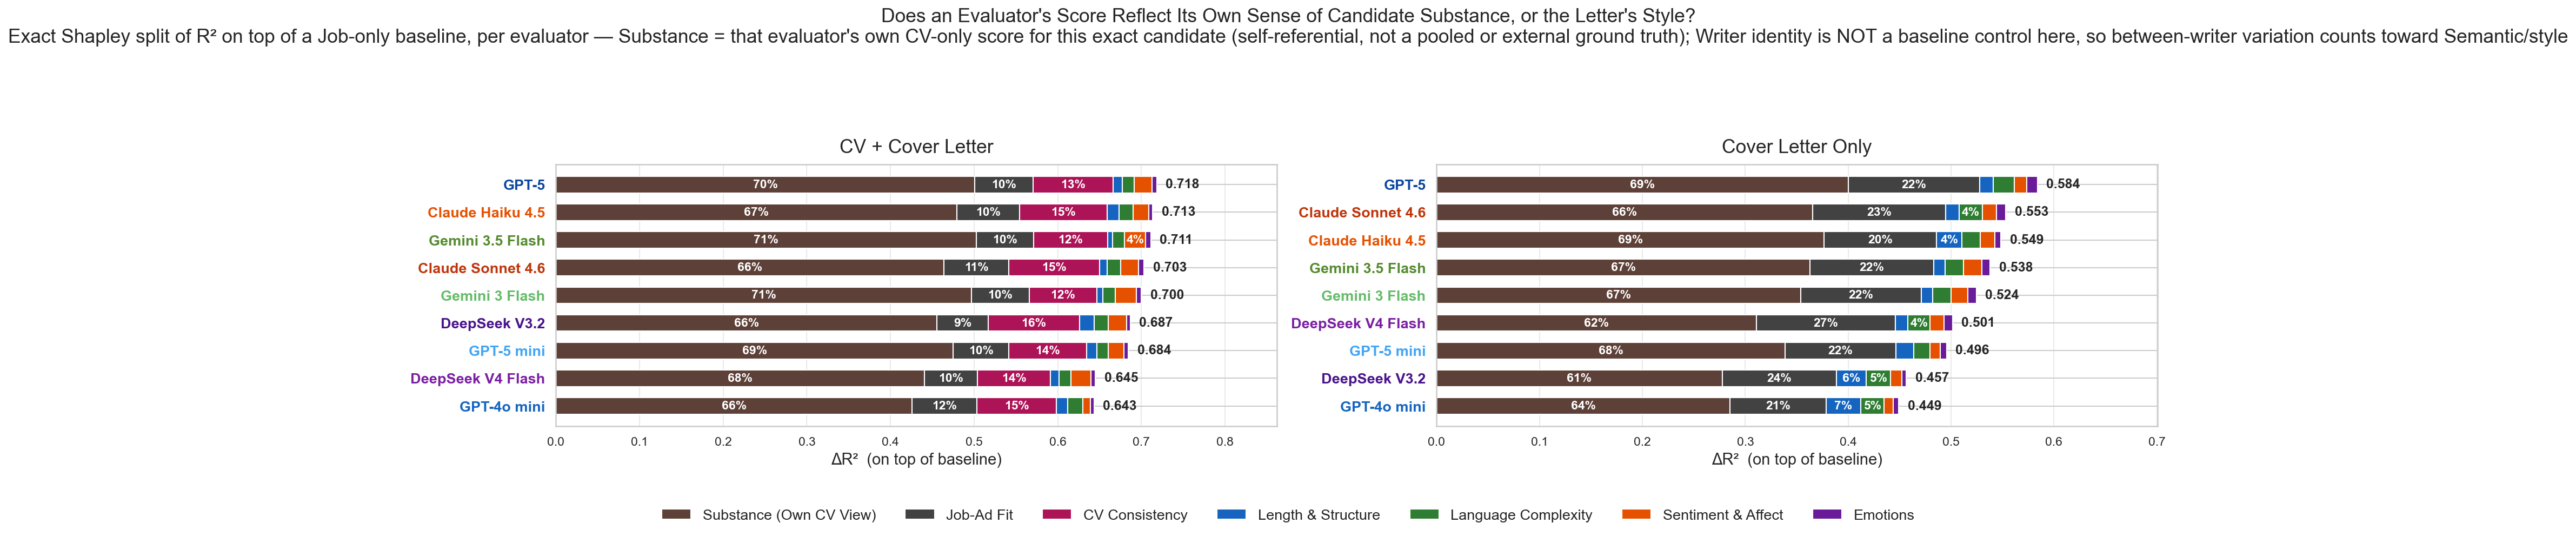

In [3]:
display(Image(f"{CL_DIR}/evaluator_substance_vs_style.png", width=1400))

**Key finding:** Substance dominates for every evaluator — 66–71% (CV+CL) / 61–69%
(Cover-Letter-Only). Splitting what used to be one combined "Semantic Fit" block reveals
something not visible before: **CV Consistency (12–16%) generally explains *more* than
Job-Ad Fit (9–12%)** when both are available. Style itself is a small remainder throughout
(each category typically ≤5%).

### 2b. Digging Into the Style Portion


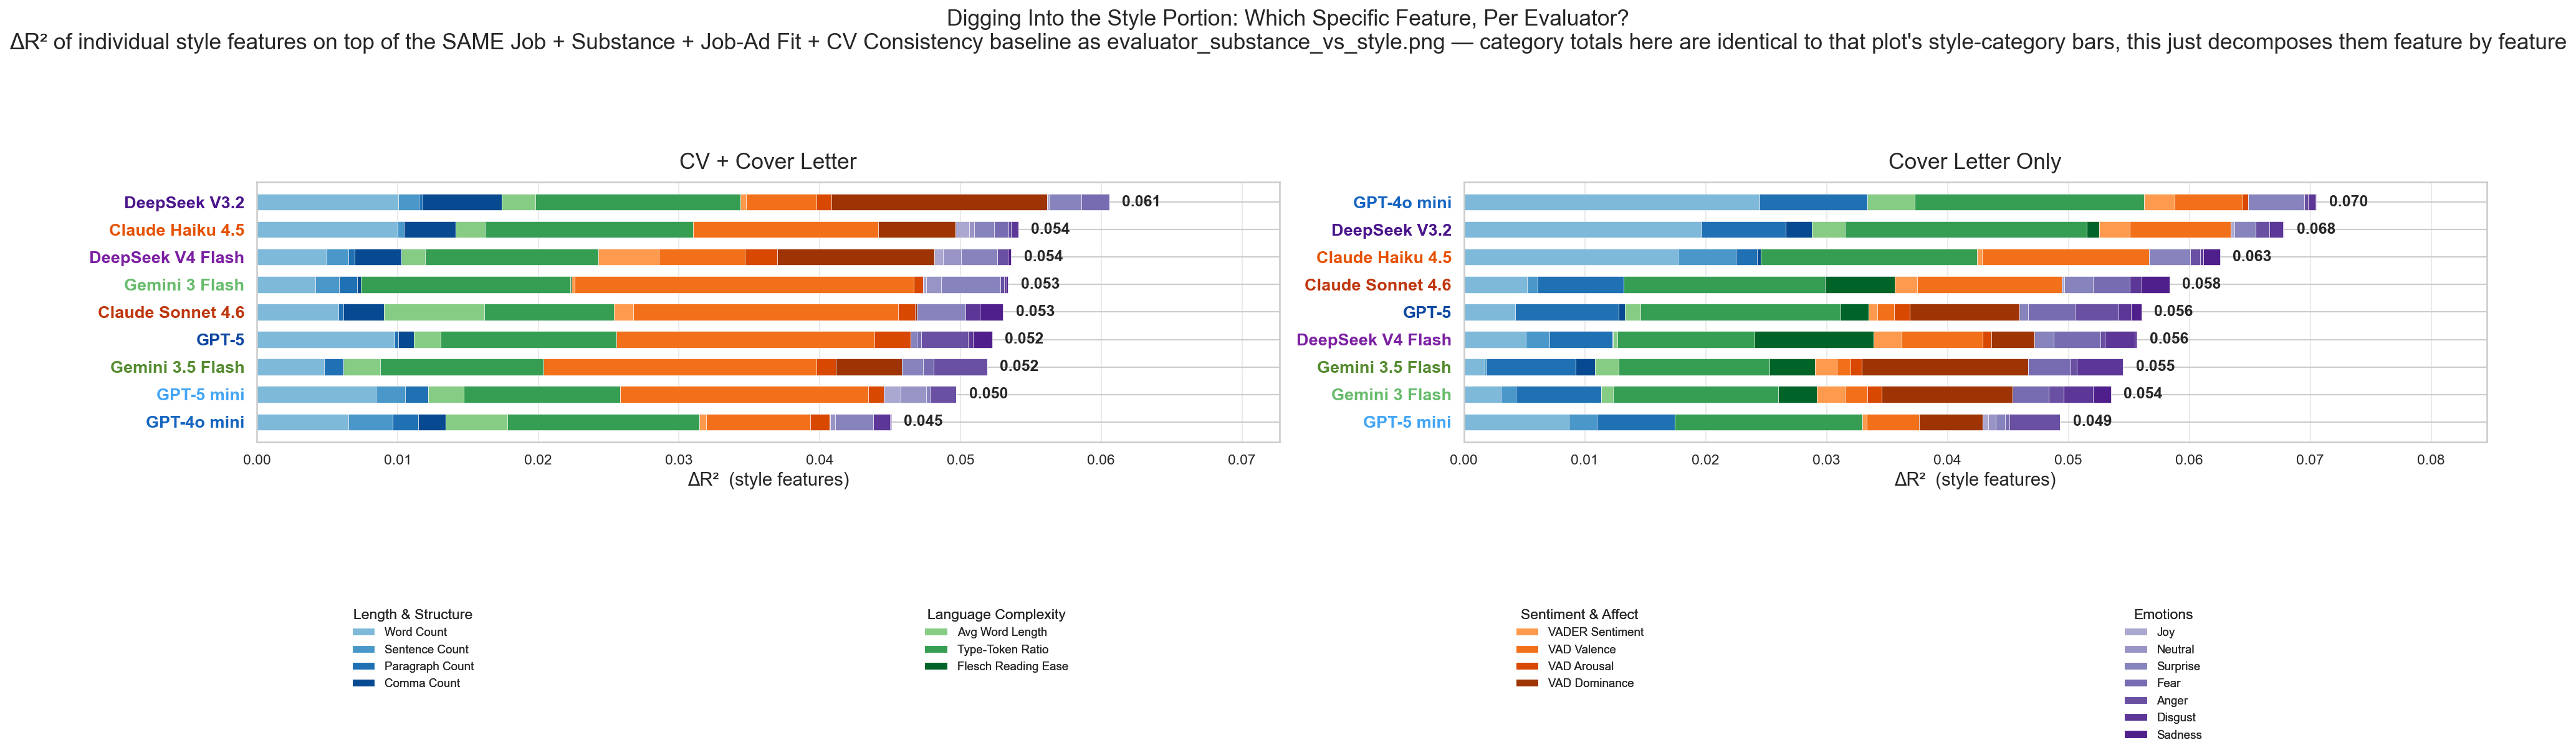

In [4]:
display(Image(f"{CL_DIR}/evaluator_style_drilldown.png", width=1400))

**Key finding:** the *relative* share of style in §2a doesn't translate directly into
*absolute* ΔR² here — **GPT-4o mini has the smallest absolute style ΔR² in CV+Cover Letter**
(0.045, the lowest of any evaluator) despite style being a comparatively larger slice of
its (smaller) total, but **the largest in Cover-Letter-Only** (0.070, now the highest) —
once the CV is gone and every evaluator's total ΔR² shrinks, GPT-4o mini's reliance on
style becomes the dominant one in absolute terms too, not just relative ones.
**DeepSeek V3.2 and DeepSeek V4 Flash lean most on Sentiment & Affect — specifically VAD
Dominance** — a large, distinct dark-red segment in both conditions; **GPT-4o mini's
Cover-Letter-Only bar is instead dominated by Length & Structure** (Word Count, Sentence
Count), consistent with notebook 2's finding that it's the one evaluator most sensitive to
verbosity and dominance/arousal together.


---
## 3. Key Takeaways

| # | Finding |
|---|---|
| 1 | **Consensus candidate quality (Substance) is overwhelmingly the largest driver of score everywhere** (+0.44 to +0.56 R²) — it dwarfs Evaluator (+0.08 to +0.18), which was already the clear second-place factor. Evaluators agree with each other on CV quality strongly enough that the group consensus nearly determines any individual evaluator's score. |
| 2 | **A cover letter adds nothing on top of the CV** — CV Only's ceiling (0.929) is actually slightly *higher* than CV+Cover Letter's (0.910/0.911). **Removing the CV entirely drops the ceiling to 0.695–0.706** — a real loss, but the letter still carries most of a candidate's consensus quality on its own. |
| 3 | **Knowing who wrote the letter (Writer) vs. what's in it (Text Features) are close but not identical**: essentially tied with a CV present (0.911 vs. 0.910), but Text Features pulls slightly ahead once the CV is gone (0.706 vs. 0.695) — the measured content explains a bit more than the writer label alone once nothing else is available. |
| 4 | **Substance (each evaluator's own CV-only judgment) dominates the explainable score variance everywhere** (61–71%), but the residual channels aren't negligible: CV Consistency generally out-explains Job-Ad Fit when both are available. |
| 5 | **Relative style share and absolute style ΔR² tell different stories**: GPT-4o mini has the *smallest* absolute style ΔR² with a CV present but the *largest* once the CV is removed — the same evaluator can look differently style-driven depending on whether you look at share or magnitude. |
| 6 | **DeepSeek V3.2 and DeepSeek V4 Flash lean most on VAD Dominance; GPT-4o mini leans most on Length & Structure** once the CV is gone — different evaluators reach for different specific style cues, not a single shared one. |
